In [13]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
import tensorflow as tf

base_model = MobileNetV3Small(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3) 
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 rescaling_3 (Rescaling)     (None, 64, 64, 3)            0         ['input_4[0][0]']             
                                                                                                  
 Conv (Conv2D)               (None, 32, 32, 16)           432       ['rescaling_3[0][0]']         
                                                                                                  
 Conv/BatchNorm (BatchNorma  (None, 32, 32, 16)           64        ['Conv[0][0]']                
 lization)                                                                                  

In [14]:
# Load images with label from directory

from tensorflow.keras.utils import image_dataset_from_directory

seed = 42
train_ds = image_dataset_from_directory(
    '../exports/spectrogram_images/train',
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
)

val_ds = image_dataset_from_directory(
    '../exports/spectrogram_images/validation',
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
)



Found 50822 files belonging to 4 classes.
Found 12713 files belonging to 4 classes.


In [15]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import tensorflow as tf

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
# test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [16]:
# compute class weights
import os
import numpy as np

train_dir = '../exports/spectrogram_images/train'
classes = os.listdir(train_dir)

class_counts = np.zeros(len(classes), dtype=int)

for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_dir, class_name)
    class_count = len(os.listdir(class_dir))
    class_counts[i] = class_count

total_samples = np.sum(class_counts)
class_weights = class_counts / total_samples
class_weights = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weights)

{0: 0.18737948132698437, 1: 0.3744834914013616, 2: 0.3440635945063162, 3: 0.09407343276533785}


In [17]:
# add patience to early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=25,
                    callbacks=[early_stop],
                    batch_size=32,
                    class_weight=class_weights)


Epoch 1/25
1589/1589 [==============================] - 93s 56ms/step - loss: 0.1711 - accuracy: 0.5565 - val_loss: 0.7199 - val_accuracy: 0.6347
Epoch 2/25
1589/1589 [==============================] - 95s 60ms/step - loss: 0.1344 - accuracy: 0.6395 - val_loss: 0.5846 - val_accuracy: 0.7186
Epoch 3/25
1589/1589 [==============================] - 89s 56ms/step - loss: 0.1221 - accuracy: 0.6735 - val_loss: 0.5904 - val_accuracy: 0.7202
Epoch 4/25
1589/1589 [==============================] - 90s 56ms/step - loss: 0.1143 - accuracy: 0.6958 - val_loss: 0.5387 - val_accuracy: 0.7492
Epoch 5/25
1589/1589 [==============================] - 90s 56ms/step - loss: 0.1095 - accuracy: 0.7084 - val_loss: 0.4946 - val_accuracy: 0.7715
Epoch 6/25
1589/1589 [==============================] - 90s 57ms/step - loss: 0.1043 - accuracy: 0.7219 - val_loss: 0.5717 - val_accuracy: 0.7415
Epoch 7/25
1589/1589 [==============================] - 92s 58ms/step - loss: 0.1015 - accuracy: 0.7307 - val_loss: 0.4726 -

In [18]:
# delete unnecessary variables

del train_ds
del val_ds

In [19]:
#export model

model.save('../exports/models/pretrained_cnn_signal.h5')

/home/samirshrestha/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


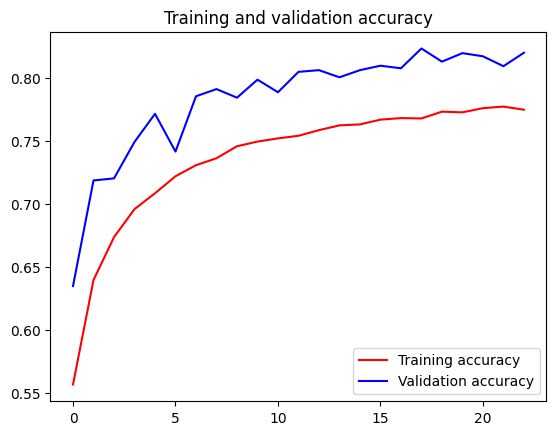

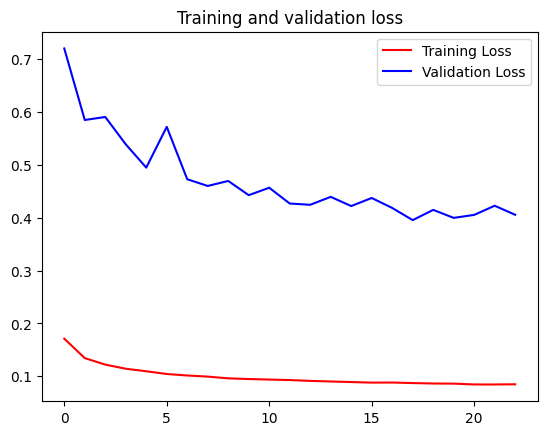

In [20]:
# Plot accuracy and loss curves

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend(loc='upper right')
plt.show()

In [21]:
# load test data

test_ds = image_dataset_from_directory(
    '../exports/spectrogram_images/test',
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
)

test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

Found 15875 files belonging to 4 classes.


In [22]:
# Evaluate model

test_loss, test_acc = model.evaluate(test_ds)
print('Test accuracy:', test_acc)

497/497 [==============================] - 23s 46ms/step - loss: 0.3744 - accuracy: 0.8329
Test accuracy: 0.8329448699951172


In [23]:
import numpy as np
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

In [24]:

from sklearn.metrics import classification_report
class_names = ['healthy', 'inner_race', 'other_fault', 'outer_race']
# order alphabetically
class_names = sorted(class_names)
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     healthy       0.92      0.84      0.88      2976
  inner_race       0.74      0.98      0.84      5952
 other_fault       0.85      0.94      0.90      1487
  outer_race       0.96      0.64      0.77      5460

    accuracy                           0.83     15875
   macro avg       0.87      0.85      0.85     15875
weighted avg       0.86      0.83      0.83     15875



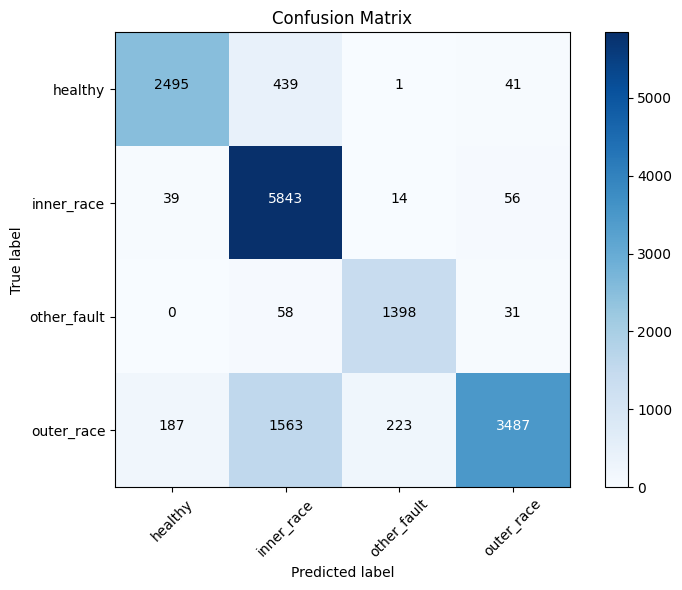

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix


# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers inside the boxes
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

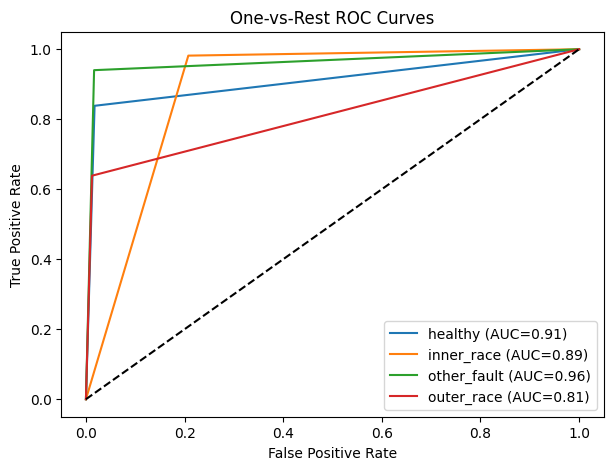

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = len(class_names)
y_test_bin = label_binarize(y_true, classes=np.arange(n_classes))
y_pred_bin = label_binarize(y_pred, classes=np.arange(n_classes))

plt.figure(figsize=(7,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("One-vs-Rest ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


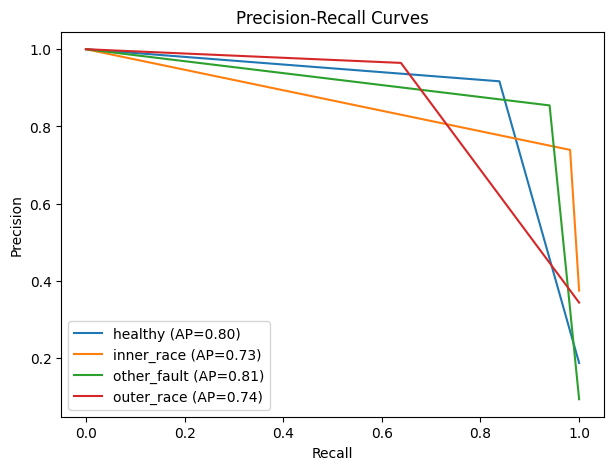

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_bin[:, i])
    plt.plot(recall, precision, label=f"{class_names[i]} (AP={ap:.2f})")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()
